<a href="https://colab.research.google.com/github/krish3453/Machine_Learning/blob/main/Normalisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['class_labels','alcohol','maleic_acid']

In [34]:
df.sample(6)

,class_labels,alcohol,maleic_acid
172,3,14.16,2.51
98,2,12.37,1.07
173,3,13.71,5.65
92,2,12.69,1.53
176,3,13.17,2.59
28,1,13.87,1.90


<Axes: xlabel='alcohol', ylabel='Density'>

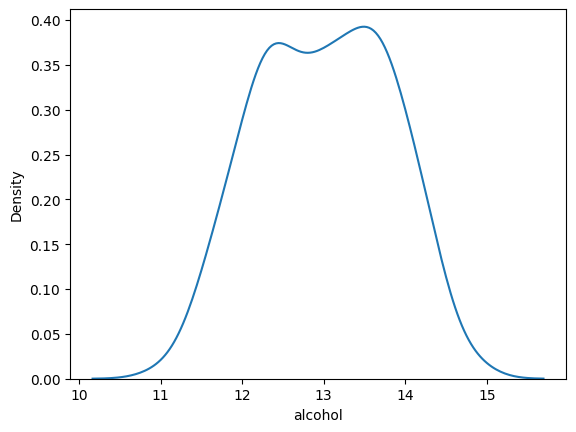

In [33]:
sns.kdeplot(df['alcohol'])

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('class_labels',axis=1),df['class_labels'],test_size=0.3)

X_train.shape,X_test.shape

((124, 2), (54, 2))

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [39]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [41]:
np.round(X_train.describe(),1)

,alcohol,maleic_acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.2
min,11.4,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.7,3.2
max,14.8,5.8


In [44]:
np.round(X_train_scaled.describe(),1)

,alcohol,maleic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.1
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


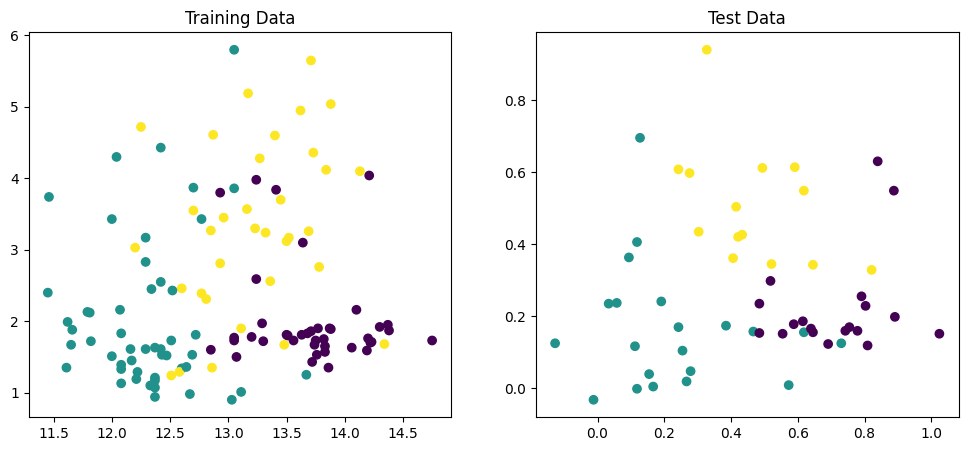

In [46]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['alcohol'],X_train['maleic_acid'],c=y_train)
ax1.set_title('Training Data')
ax2.scatter(X_test_scaled['alcohol'],X_test_scaled['maleic_acid'],c=y_test)
ax2.set_title('Test Data')
plt.show()